<div style="display: flex; align-items: center; justify-content: center; gap: 20px;">
  <!-- Left Column: Image -->
  <div style="flex: 1; text-align: center;">
    <img src="https://i0.wp.com/cdcs.web.ua.pt/wp-content/uploads/2022/05/cropped-cropped-Picture13-1.png?w=968" width="370" height="200" style="display: block; margin: auto;"/>
  </div>

  <!-- Right Column: Text -->
  <div style="flex: 1; text-align: left;">
    <div><strong style="color: #4F5B63; font-size: 1.5em;">Master in Data Science for Social Sciences</strong></div>
    <div><strong style="color: #4F5B63; font-size: 1.2em;">University of Aveiro</strong></div>
    <p style="color: #46627F; font-weight: bold; font-style: italic;">Introduction to Data Science - 2025/2026</p>
    <p style="color: #4F5B63;">João Lourenço Marques</p>
    <p style="color: #4F5B63;">Paulo Batista</p>
  </div>
</div>


<div style="display: flex; justify-content: space-around; align-items: flex-start;">
  <div style="width: 100%; padding: 10px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); margin: 10px;">
    <h2><h1 style="text-align: center; font-size: 4em; color: #46627F; margin-top: 0; margin-bottom: 0; line-height: 1;">Bibliometric Data and Exploratory Analysis </h1>
<p>
<h1 style="text-align: center; color: #B1C0CF; margin-top: 0; margin-bottom: 0; line-height: 1;"> - Get Scopus DataBase from API- </h1> 
</p>
</h2>
      </div>
</div>

In [1]:
import requests
import pandas as pd
import time
import matplotlib.pyplot as plt

import os
import sys
from decouple import Config, RepositoryEnv


import math

In [2]:
# Set up project root as working directory

from pathlib import Path

# Find the project root (assuming marker-based or script-relative path)
def find_project_root(marker="README.md"):
    current_dir = Path.cwd()
    while current_dir != current_dir.parent:  # Traverse up until root
        if (current_dir / marker).exists():
            return current_dir
        current_dir = current_dir.parent
    raise FileNotFoundError(f"Marker '{marker}' not found in any parent directory.")

project_root = find_project_root()
sys.path.append(str(project_root)) 

# Or use a relative path: project_root = Path(__file__).resolve().parent.parent
os.chdir(project_root)
print(f"Working directory set to: {project_root}")

Working directory set to: c:\Users\paulo\OneDrive\TRABALHO_AULAS\AL20252026\1S_ICD\TP\projICD


## Configuração Chave API

You can get your API key by creating an account at https://dev.elsevier.com/apikey/manage and generating a new key.

In [3]:
from decouple import config

# https://medium.com/@alensabu12xtz/configure-environment-variables-with-python-decouple-b5f5446381a3

MY_SCOPUS_API_KEY = config('MY_SCOPUS_API_KEY')

# print('my scopus api key is :', MY_SCOPUS_API_KEY) 

In [4]:
from decouple import Config, RepositoryEnv

DOTENV_FILE = './.env'
env_config = Config(RepositoryEnv(DOTENV_FILE))



# use the Config().get() method as you normally would since 
# decouple.config uses that internally. 
# i.e. config('SECRET_KEY') = env_config.get('SECRET_KEY')
MY_SCOPUS_API_KEY = env_config.get('MY_SCOPUS_API_KEY')

# print('my scopus api key is :', MY_SCOPUS_API_KEY) 

# Download data from Scopus API using your API key stored in a .env file

In [5]:
# Defina a sua chave de API da Elsevier
api_key = MY_SCOPUS_API_KEY
# query = "data science AND social science" 
query = ' "Smart Cities" AND "Open Data Infrastructure" OR "Government Open Data" OR "Administrative Open Data" ' # Tema dos artigos
url = "https://api.elsevier.com/content/search/scopus"

## First run on Scopus API to get search results (identify total number of records)

In [6]:
# IMPORTANTE: https://dev.elsevier.com/sc_search_tips.html


responseScopus = requests.get("https://api.elsevier.com/content/search/scopus",
                    headers={'Accept':'application/json',
                             'X-ELS-APIKey': MY_SCOPUS_API_KEY},
                         
                    params={    'query' : query,
                                #'start' : "1"
                        }

                        )

print(responseScopus.url)

dataScopus_json = responseScopus.json() 



https://api.elsevier.com/content/search/scopus?query=+%22Smart+Cities%22+AND+%22Open+Data+Infrastructure%22+OR+%22Government+Open+Data%22+OR+%22Administrative+Open+Data%22+


In [7]:
# Visualize first record
dataScopus_json.get("search-results", {}).get("entry")[0]

{'@_fa': 'true',
 'link': [{'@_fa': 'true',
   '@ref': 'self',
   '@href': 'https://api.elsevier.com/content/abstract/scopus_id/105012602138'},
  {'@_fa': 'true',
   '@ref': 'author-affiliation',
   '@href': 'https://api.elsevier.com/content/abstract/scopus_id/105012602138?field=author,affiliation'},
  {'@_fa': 'true',
   '@ref': 'scopus',
   '@href': 'https://www.scopus.com/inward/record.uri?partnerID=HzOxMe3b&scp=105012602138&origin=inward'},
  {'@_fa': 'true',
   '@ref': 'scopus-citedby',
   '@href': 'https://www.scopus.com/inward/citedby.uri?partnerID=HzOxMe3b&scp=105012602138&origin=inward'}],
 'prism:url': 'https://api.elsevier.com/content/abstract/scopus_id/105012602138',
 'dc:identifier': 'SCOPUS_ID:105012602138',
 'eid': '2-s2.0-105012602138',
 'dc:title': 'Digital Twin or Digital Kin: Misunderstandings and Myths about Urban Simulation, and Directions for Change',
 'dc:creator': 'Payne W.B.',
 'prism:publicationName': 'Journal of Planning Education and Research',
 'prism:issn'

In [8]:
total_results = dataScopus_json.get("search-results", {}).get("opensearch:totalResults")
print("Total Results:", total_results)

Total Results: 265


In [9]:
# Campos a extrair
fields = ",".join([
    "dc:title", "dc:creator", "prism:publicationName", "prism:doi", "affiliation", "citedby-count",
    "pubmed-id", "issn", "isbn", "abstract", "author-keywords", "index-keywords", "publisher",
    "funding-text", "conference-name", "conference-date", "language", "source", "eid"
])

The following script block includes a get_abstract() function, to connect to the Abstract Retrieval API endpoint to fetch the full abstract for each article using its EID (Elsevier ID) obtained from the initial search results / search endpoint.

Thus, this is a two-step retrieval process:

First, the Search API (https://dev.elsevier.com/documentation/ScopusSearchAPI.wadl) retrieves basic metadata
Then, for each article, the Abstract Retrieval API (https://dev.elsevier.com/documentation/AbstractRetrievalAPI.wadl) fetches the full abstract
Rate limiting: It consider a 0.5-second delay between abstract retrievals to respect API rate limits while still being efficient.

Progress tracking: Include a print statements to monitor the collection progress.

Error handling: The get_abstract() function includes try-except to handle potential errors gracefully.

The data retrieved from both API endpoints is combined into a single DataFrame for further analysis.

From Search API:

- Title, Authors, Journal
- DOI, Year, Cover Date
- Citations count
- Affiliations
- Author Keywords, Index Keywords
- Document Type, Source Type
- Open Access status
- Publisher, ISSN, ISBN
- Volume, Issue, Page Range
- Conference information (Name, Location, Date)
- Language
- PubMed ID, Funding information
- EID, Scopus ID, Source ID
- Direct link to Scopus record


Additional metadata from Abstract Retrieval API:

- Full abstract text
- Abstract language
- Enhanced document type information
- More detailed open access flags
- Article number
- Additional volume/issue/page details

In [31]:
# Function to retrieve abstract and additional metadata using Abstract Retrieval API
def get_abstract_and_metadata(eid, api_key):
    """
    Retrieve abstract and additional metadata for a given EID using the Abstract Retrieval API
    Returns a dictionary with abstract and other metadata
    """
    if not eid:
        return {"abstract": None}
    
    abstract_url = f"https://api.elsevier.com/content/abstract/eid/{eid}"
    headers = {
        'Accept': 'application/json',
        'X-ELS-APIKey': api_key
    }
    
    try:
        response = requests.get(abstract_url, headers=headers)
        if response.status_code == 200:
            data = response.json()
            # Navigate through the JSON structure to find the abstract and metadata
            abstract_data = data.get('abstracts-retrieval-response', {})
            coredata = abstract_data.get('coredata', {})
            
            # Extract comprehensive metadata
            metadata = {
                'abstract': coredata.get('dc:description', None),
                'abstract_language': coredata.get('language', {}).get('@xml:lang', None) if isinstance(coredata.get('language'), dict) else None,
                'document_type': coredata.get('subtypeDescription', None),
                'source_type': coredata.get('srctype', None),
                'open_access': coredata.get('openaccess', None),
                'openaccessFlag': coredata.get('openaccessFlag', None),
                'cover_date': coredata.get('prism:coverDate', None),
                'volume': coredata.get('prism:volume', None),
                'issue': coredata.get('prism:issueIdentifier', None),
                'page_range': coredata.get('prism:pageRange', None),
                'article_number': coredata.get('article-number', None),
            }
            
            return metadata
        else:
            return {"abstract": None}
    except Exception as e:
        print(f"Error retrieving data for EID {eid}: {e}")
        return {"abstract": None}

# Inicializar variáveis para paginação e armazenamento de resultados
start = 0
all_articles = []
max_results_per_request = 25  # Limite máximo da API por requisição
request_limit = 20000  # Rate limits: 20,000 requests per week for Scopus API see on: https://dev.elsevier.com/api_key_settings.html
cursor = "*"

# Parâmetros da requisição
params = {
    "query": query,
    "apiKey": api_key,
    "count": 25,  # Número máximo de artigos por requisição
    "start": 0,
    "field": fields,  # Especificando os campos
    "cursor" : cursor
}

print(f"Starting data collection for {total_results} articles...")

for i in range(0, math.ceil(int(total_results) / int(max_results_per_request))):
    
    print(f"Fetching batch {i+1}/{math.ceil(int(total_results) / int(max_results_per_request))}...")
    
    # Envio da requisição GET
    response = requests.get(url, params=params)
    data = response.json()  # Dados em formato JSON

    # Verificar e processar os resultados
    if response.status_code == 200:
        articles = data.get("search-results", {}).get("entry", [])
        
        # Extrair dados e armazenar em um DataFrame
        articles_data = []
        for article in articles:
            eid = article.get("eid")
            
            # Retrieve abstract and additional metadata using Abstract Retrieval API
            additional_metadata = get_abstract_and_metadata(eid, api_key)
            time.sleep(0.5)  # Small delay to respect rate limits
            
            # Extract year from prism:coverDisplayDate or prism:coverDate
            cover_date = article.get("prism:coverDate") or additional_metadata.get('cover_date')
            year = None
            if cover_date:
                try:
                    year = int(cover_date.split('-')[0])
                except:
                    year = None
            
            # Get open access information from both sources
            open_access_search = article.get("openaccess")
            open_access_abstract = additional_metadata.get('open_access') or additional_metadata.get('openaccessFlag')
            open_access = open_access_abstract if open_access_abstract is not None else open_access_search
            
            # Get document type from both sources
            doc_type_search = article.get("subtypeDescription") or article.get("subtype")
            doc_type_abstract = additional_metadata.get('document_type')
            document_type = doc_type_abstract if doc_type_abstract else doc_type_search
            
            # Extract author keywords - handle different possible formats
            author_keywords = article.get("authkeywords")
            if not author_keywords:
                author_keywords = article.get("author-keywords")
            
            article_info = {
                "Title": article.get("dc:title"),
                "Authors": article.get("dc:creator"),
                "Journal": article.get("prism:publicationName"),
                "DOI": article.get("prism:doi"),
                "Year": year,
                "Cover Date": cover_date,
                "Cited by": article.get("citedby-count"),
                "Affiliations": article.get("affiliation"),
                "Abstract": additional_metadata.get('abstract'),
                "Abstract Language": additional_metadata.get('abstract_language'),
                "Author Keywords": author_keywords,
                "Index Keywords": article.get("idxterms"),
                "Document Type": document_type,
                "Source Type": additional_metadata.get('source_type') or article.get("prism:aggregationType"),
                "Open Access": open_access,
                "Publisher": article.get("dc:publisher"),
                "ISSN": article.get("prism:issn"),
                "ISBN": article.get("prism:isbn"),
                "Volume": additional_metadata.get('volume') or article.get("prism:volume"),
                "Issue": additional_metadata.get('issue') or article.get("prism:issueIdentifier"),
                "Page Range": additional_metadata.get('page_range') or article.get("prism:pageRange"),
                "Article Number": additional_metadata.get('article_number'),
                "Conference Name": article.get("prism:conferenceName"),
                "Conference Location": article.get("prism:conferenceLocation"),
                "Conference Date": article.get("prism:conferenceDate"),
                "Language": article.get("language") or additional_metadata.get('abstract_language'),
                "PubMed ID": article.get("pubmed-id"),
                "Funding Text": article.get("fund-sponsor"),
                "EID": eid,
                "Scopus ID": article.get("dc:identifier"),
                "Source ID": article.get("source-id"),
                "Link": article.get("prism:url") or f"https://www.scopus.com/record/display.uri?eid={eid}&origin=resultslist"
            }
            articles_data.append(article_info)
        
        wait_time = 1  # Tempo de espera em segundos
        time.sleep(wait_time)  # Pausa para evitar exceder o limite de requisição
        all_articles.extend(articles_data)
        cursor = data["search-results"]["cursor"]['@next']
        params.update(cursor=cursor)
        
        print(f"Collected {len(all_articles)} articles so far...")

print(f"\nData collection complete! Total articles: {len(all_articles)}")

Starting data collection for 265 articles...
Fetching batch 1/11...
Collected 25 articles so far...
Fetching batch 2/11...
Collected 25 articles so far...
Fetching batch 2/11...
Collected 50 articles so far...
Fetching batch 3/11...
Collected 50 articles so far...
Fetching batch 3/11...
Collected 75 articles so far...
Fetching batch 4/11...
Collected 75 articles so far...
Fetching batch 4/11...
Collected 100 articles so far...
Fetching batch 5/11...
Collected 100 articles so far...
Fetching batch 5/11...
Collected 125 articles so far...
Fetching batch 6/11...
Collected 125 articles so far...
Fetching batch 6/11...
Collected 150 articles so far...
Fetching batch 7/11...
Collected 150 articles so far...
Fetching batch 7/11...
Collected 175 articles so far...
Fetching batch 8/11...
Collected 175 articles so far...
Fetching batch 8/11...
Collected 200 articles so far...
Fetching batch 9/11...
Collected 200 articles so far...
Fetching batch 9/11...
Collected 225 articles so far...
Fetching 

___________

In [32]:
# Criar DataFrame
dfScopus = pd.DataFrame(all_articles)
dfScopus.iloc[[0,-1]] # Exibe o DataFrame


,Title,Authors,Journal,DOI,Year,Cover Date,Cited by,Affiliations,Abstract,Abstract Language,...,Conference Name,Conference Location,Conference Date,Language,PubMed ID,Funding Text,EID,Scopus ID,Source ID,Link
0,From disclosure to discrepancy: How open gover...,Hu J.,Government Information Quarterly,10.1016/j.giq.2025.102085,2025,2025-12-01,0,"[{'@_fa': 'true', 'affiliation-url': 'https://...","Given the impact of environmental, social, and...",None,...,None,None,None,None,None,None,2-s2.0-105020574618,None,None,https://api.elsevier.com/content/abstract/scop...
264,Towards ecosystems based on open data as a ser...,Gama K.,Iceis 2014 Proceedings of the 16th Internation...,None,2014,2014-01-01,15,"[{'@_fa': 'true', 'affiliation-url': 'https://...",Despite several efforts in contests throughout...,None,...,None,None,None,None,None,None,2-s2.0-84902354877,None,None,https://api.elsevier.com/content/abstract/scop...


In [33]:
dfScopus.columns

Index(['Title', 'Authors', 'Journal', 'DOI', 'Year', 'Cover Date', 'Cited by',
       'Affiliations', 'Abstract', 'Abstract Language', 'Author Keywords',
       'Index Keywords', 'Document Type', 'Source Type', 'Open Access',
       'Publisher', 'ISSN', 'ISBN', 'Volume', 'Issue', 'Page Range',
       'Article Number', 'Conference Name', 'Conference Location',
       'Conference Date', 'Language', 'PubMed ID', 'Funding Text', 'EID',
       'Scopus ID', 'Source ID', 'Link'],
      dtype='object')

In [34]:
dfScopus.Abstract

0      Given the impact of environmental, social, and...
1      A data catalog enables an organization to main...
2      Using three case studies from the United State...
3      Digital government research lies at the inters...
4      Public Data Ecosystems (PDEs) are increasingly...
                             ...                        
260    In urban areas, public transit plays a signifi...
261    One of the significant challenges facing the d...
262    Open data is an important trend being consider...
263    The proceedings contain 57 papers. The topics ...
264    Despite several efforts in contests throughout...
Name: Abstract, Length: 265, dtype: object

In [35]:
dfScopus.Affiliations[0]

[{'@_fa': 'true',
  'affiliation-url': 'https://api.elsevier.com/content/affiliation/affiliation_id/60017605',
  'afid': '60017605',
  'affilname': 'Fuzhou University',
  'affiliation-city': 'Fuzhou',
  'affiliation-country': 'China'},
 {'@_fa': 'true',
  'affiliation-url': 'https://api.elsevier.com/content/affiliation/affiliation_id/60004630',
  'afid': '60004630',
  'affilname': 'Fujian Agriculture and Forestry University',
  'affiliation-city': 'Fuzhou',
  'affiliation-country': 'China'},
 {'@_fa': 'true',
  'affiliation-url': 'https://api.elsevier.com/content/affiliation/affiliation_id/60017431',
  'afid': '60017431',
  'affilname': 'Zhejiang University of Science and Technology',
  'affiliation-city': 'Hangzhou',
  'affiliation-country': 'China'}]

In [36]:
# Reset index to ensure it's preserved as a column
dfAffiliations = dfScopus[['Affiliations']].copy()
dfAffiliations['original_index'] = dfScopus.index

# Explode the affiliations while preserving the original index
dfAffiliations_exploded = pd.json_normalize(
    dfAffiliations.to_dict('records'),
    record_path='Affiliations',
    meta=['original_index'],
    errors='ignore'  # Skips over missing keys
)

In [37]:
dfAffiliations_exploded.iloc[[0,-1]]

,@_fa,affiliation-url,afid,affilname,affiliation-city,affiliation-country,original_index
0,true,https://api.elsevier.com/content/affiliation/a...,60017605,Fuzhou University,Fuzhou,China,0
522,true,https://api.elsevier.com/content/affiliation/a...,60031482,Universidade Federal de Pernambuco,Recife,Brazil,264


In [38]:

# Salvar o DataFrame em um arquivo CSV
dfScopus.to_csv(r'./data/dfScopus_bibliometric.csv', index=False)

# Analyze Key Bibliometric Indicators

### Summary of the Structure

#### **How Many?**
Explore counts and distributions of articles, authors, and citations to measure research productivity and impact.

- **Total Articles**: Count the number of articles in the dataset.
- **Top Authors by Productivity**: Use `Authors` to identify the most prolific authors.
- **Top Cited Articles**: Sort by `Cited by` to find the articles with the highest impact.
- **Most Frequent Document Types**: Analyze `Document Type` to see the distribution of different publication types (e.g., articles, reviews, conference papers).
- **Open Access vs. Closed Access**: Count and compare documents marked as `Open Access` vs. non-open access.

#### **When?**
Analyze temporal aspects to see trends over time in publication and citations.

- **Publications per Year**: Use `Year` to show trends in publications.
- **Citations per Year**: Sum `Cited by` by year to see citation trends.
- **Trends in Open Access Publications**: Track the increase in `Open Access` publications over time.
- **Publication Stage Trends**: Analyze `Publication Stage` (e.g., "Final" vs. "In Press") by year to understand publishing workflows.

#### **Where?**
Focus on sources, affiliations, and publication venues to understand where research is concentrated.

- **Top Journals by Number of Articles**: Use `Source title` to identify the most frequent publication venues.
- **Top Affiliations**: Analyze `Affiliations` to see which institutions are most active.
- **Geographic Distribution of Research**: If `Conference location` has country or region data, use it to map out geographic concentrations.
- **Frequent Conference Venues**: Use `Conference name` and `Conference location` to identify popular conferences in the field.
- **Top Publishers**: Count occurrences in `Publisher` to identify the main publishers in this area of research.

#### **What?**
Analyze topics, keywords, research focus, and funding patterns.

- **Top Keywords**: Use `Author Keywords` and `Index Keywords` to find common research topics.
- **Frequent Chemicals/CAS Numbers**: If relevant to your field, analyze `Chemicals/CAS` to identify frequently studied chemicals.
- **Common Funding Sources**: Use `Funding Details` or `Funding Texts` to identify major funding bodies or grants.
- **Abstract Word Cloud**: Generate a word cloud from `Abstract` text to visually identify common themes.
- **Research Sponsors**: Analyze `Sponsors` to see which organizations support this research.
- **Research on Molecular Sequences**: Count unique `Molecular Sequence Numbers` if applicable to study trends in sequence-based research.
- **Language of Publication**: Count occurrences in `Language of Original Document` to understand the language distribution in the research field.


## Part 1: How Many?
In this section, we analyze counts, such as the number of articles, citations, authors, and other similar metrics.

In [39]:
# Total number of articles
total_articles = dfScopus.shape[0]
print(f"Total number of articles: {total_articles}")

Total number of articles: 265


In [54]:
dfScopus[['Cited by']] = dfScopus[['Cited by']].apply(pd.to_numeric, errors='coerce')

In [56]:
# Most Frequently Cited Articles
top_cited_articles = dfScopus[['Title', 'Cited by']].sort_values(by='Cited by', ascending=False).head(10)
print("Top 10 Most Cited Articles:")
print(top_cited_articles)

Top 10 Most Cited Articles:
                                                 Title  Cited by
251  A systematic review of open government data in...       711
153  Implications of the use of artificial intellig...       453
243  Utilization of open government data: A systema...       244
253  Civic open data at a crossroads: Dominant mode...       234
232       Big data for policymaking: fad or fasttrack?       175
192  Investigations into Data Ecosystems: a systema...       168
246  State-of-the-art in open data research: Insigh...       154
176  A systematic review of big data-based urban su...       136
158  Open government data portal usability: A user-...       103
182  Securing parked vehicle assisted fog computing...       102


In [57]:
# Most Productive Authors
author_counts = dfScopus['Authors'].str.split(', ').explode().value_counts().head(10)
print("Top 10 Most Productive Authors:")
print(author_counts)

Top 10 Most Productive Authors:
Authors
Nikiforova A.     5
Lnenicka M.       4
Johnson P.A.      4
Shaharudin A.     3
Matheus R.        3
Martins T.C.M.    3
Zuiderwijk A.     3
Alexopoulos C.    3
Begany G.M.       2
Liu X.            2
Name: count, dtype: int64


In [58]:
dfScopus.columns

Index(['Title', 'Authors', 'Journal', 'DOI', 'Year', 'Cover Date', 'Cited by',
       'Affiliations', 'Abstract', 'Abstract Language', 'Author Keywords',
       'Index Keywords', 'Document Type', 'Source Type', 'Open Access',
       'Publisher', 'ISSN', 'ISBN', 'Volume', 'Issue', 'Page Range',
       'Article Number', 'Conference Name', 'Conference Location',
       'Conference Date', 'Language', 'PubMed ID', 'Funding Text', 'EID',
       'Scopus ID', 'Source ID', 'Link'],
      dtype='object')

In [59]:
# Open Access vs. Closed Access counts
open_access_counts = dfScopus['Open Access'].value_counts()
print("Open Access vs. Closed Access:")
print(open_access_counts)

Open Access vs. Closed Access:
Open Access
0    110
1    107
2     11
Name: count, dtype: int64


<Axes: xlabel='Open Access'>

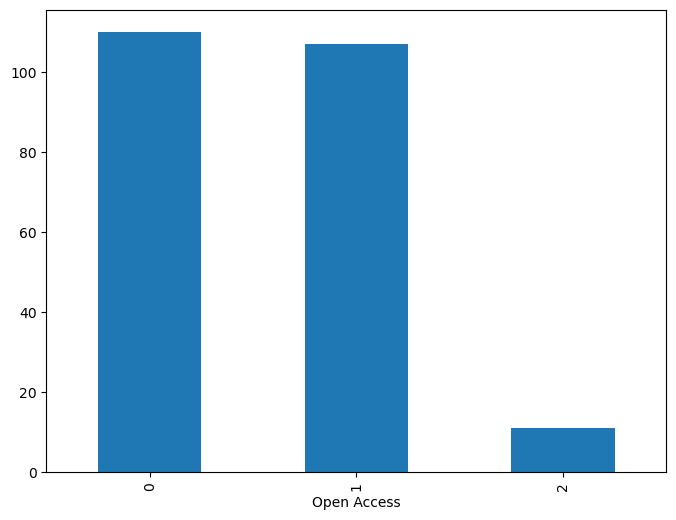

In [60]:
# Plotting the bar chart
plt.figure(figsize=(8, 6))
open_access_counts.plot(kind='bar')

## Part 2: When?
This part will focus on temporal aspects, analyzing trends over time. For instance, it may examine how many articles were published each year.

In [45]:
dfScopus['Year']

0      2025
1      2025
2      2025
3      2025
4      2025
       ... 
260    2014
261    2014
262    2014
263    2014
264    2014
Name: Year, Length: 265, dtype: int64

In [47]:
# Yearly publication trends
yearly_publications = dfScopus['Year'].value_counts().sort_index()
print("Yearly Publication Trends:")
print(yearly_publications)


Yearly Publication Trends:
Year
2014     6
2015     8
2016     6
2017    16
2018    17
2019    21
2020    16
2021    33
2022    25
2023    40
2024    37
2025    40
Name: count, dtype: int64


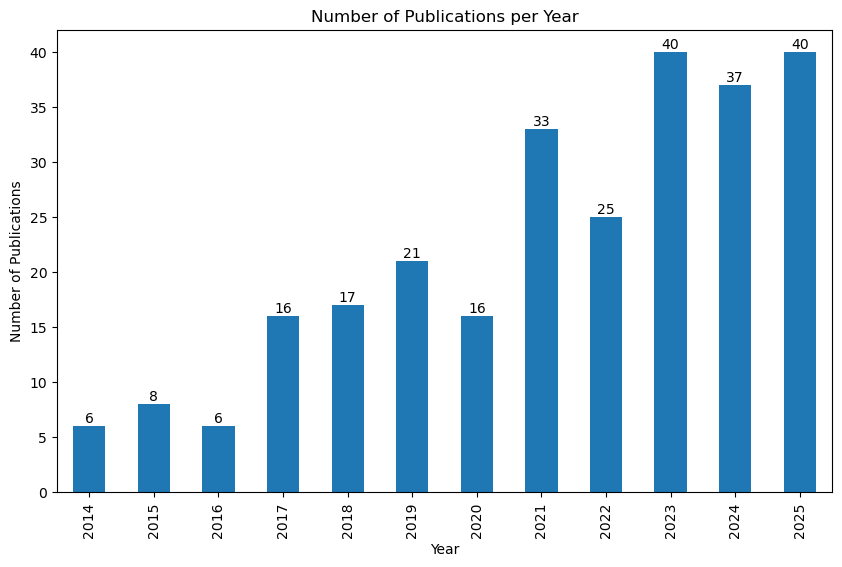

In [48]:
# Plot the number of publications per year
plt.figure(figsize=(10, 6))
ax = yearly_publications.plot(kind='bar', title='Number of Publications per Year')
plt.xlabel("Year")
plt.ylabel("Number of Publications")

# Add labels on top of each bar
ax.bar_label(ax.containers[0])

plt.show()

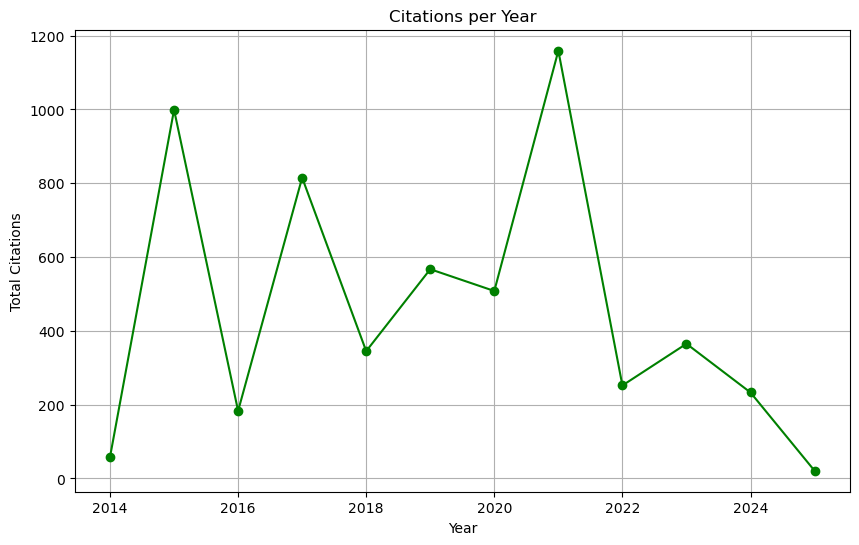

In [61]:
# Sum citations by year
citations_per_year = dfScopus.groupby('Year')['Cited by'].sum()

# Plot citations per year
plt.figure(figsize=(10, 6))
citations_per_year.plot(kind='line', marker='o', color='green', title='Citations per Year')
plt.xlabel("Year")
plt.ylabel("Total Citations")
plt.grid(True)
plt.show()

In [62]:
# Display unique values in 'Open Access' column to check for inconsistencies
print(dfScopus['Open Access'].unique())

['0' '1' '2' None]


<Figure size 1000x600 with 0 Axes>

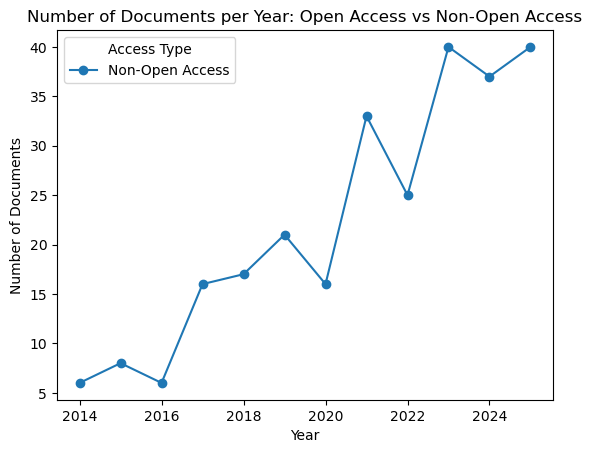

In [63]:
# Create a binary column to indicate open access status
dfScopus['Is Open Access'] = dfScopus['Open Access'].str.contains("all open access", na=False)

# Group by 'Year' and 'Is Open Access', then count the number of documents
documents_by_access = dfScopus.groupby(['Year', 'Is Open Access']).size().unstack(fill_value=0)

# Plot quantity of documents per year for open and non-open access
plt.figure(figsize=(10, 6))
documents_by_access.plot(kind='line', marker='o', title='Number of Documents per Year: Open Access vs Non-Open Access')
plt.xlabel("Year")
plt.ylabel("Number of Documents")
plt.legend(["Non-Open Access", "Open Access"], title="Access Type")
plt.show()


<Figure size 1000x600 with 0 Axes>

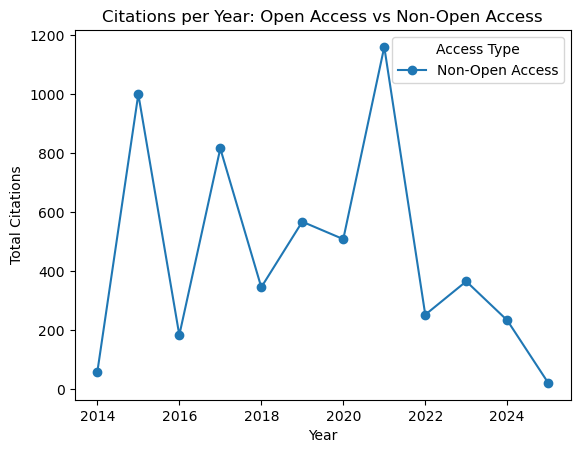

In [64]:
# Create a binary column to indicate open access status
dfScopus['Is Open Access'] = dfScopus['Open Access'].str.contains("all open access", na=False)

# Group by 'Year' and 'Is Open Access', then sum citations
citations_by_access = dfScopus.groupby(['Year', 'Is Open Access'])['Cited by'].sum().unstack(fill_value=0)

# Plot citations per year for open and non-open access
plt.figure(figsize=(10, 6))
citations_by_access.plot(kind='line', marker='o', title='Citations per Year: Open Access vs Non-Open Access')
plt.xlabel("Year")
plt.ylabel("Total Citations")
plt.legend(["Non-Open Access", "Open Access"], title="Access Type")
plt.show()


## Part 3: Where?
This section will examine where the research has been published, looking into journals, conferences, and affiliations.

In [66]:
dfScopus.columns

Index(['Title', 'Authors', 'Journal', 'DOI', 'Year', 'Cover Date', 'Cited by',
       'Affiliations', 'Abstract', 'Abstract Language', 'Author Keywords',
       'Index Keywords', 'Document Type', 'Source Type', 'Open Access',
       'Publisher', 'ISSN', 'ISBN', 'Volume', 'Issue', 'Page Range',
       'Article Number', 'Conference Name', 'Conference Location',
       'Conference Date', 'Language', 'PubMed ID', 'Funding Text', 'EID',
       'Scopus ID', 'Source ID', 'Link', 'Is Open Access'],
      dtype='object')

In [67]:
# Most Cited Journals
journal_citations = dfScopus.groupby('Journal')['Cited by'].sum().sort_values(ascending=False).head(10)
print("Top 10 Most Cited Journals:")
print(journal_citations)

Top 10 Most Cited Journals:
Journal
Government Information Quarterly                               1935
Information Polity                                              288
Sustainability Switzerland                                      266
Telematics and Informatics                                      226
Policy Sciences                                                 175
Journal of Organizational Computing and Electronic Commerce     170
Knowledge and Information Systems                               168
Information Systems Frontiers                                   140
Journal of Cleaner Production                                   136
Applied Sciences Switzerland                                    115
Name: Cited by, dtype: int64


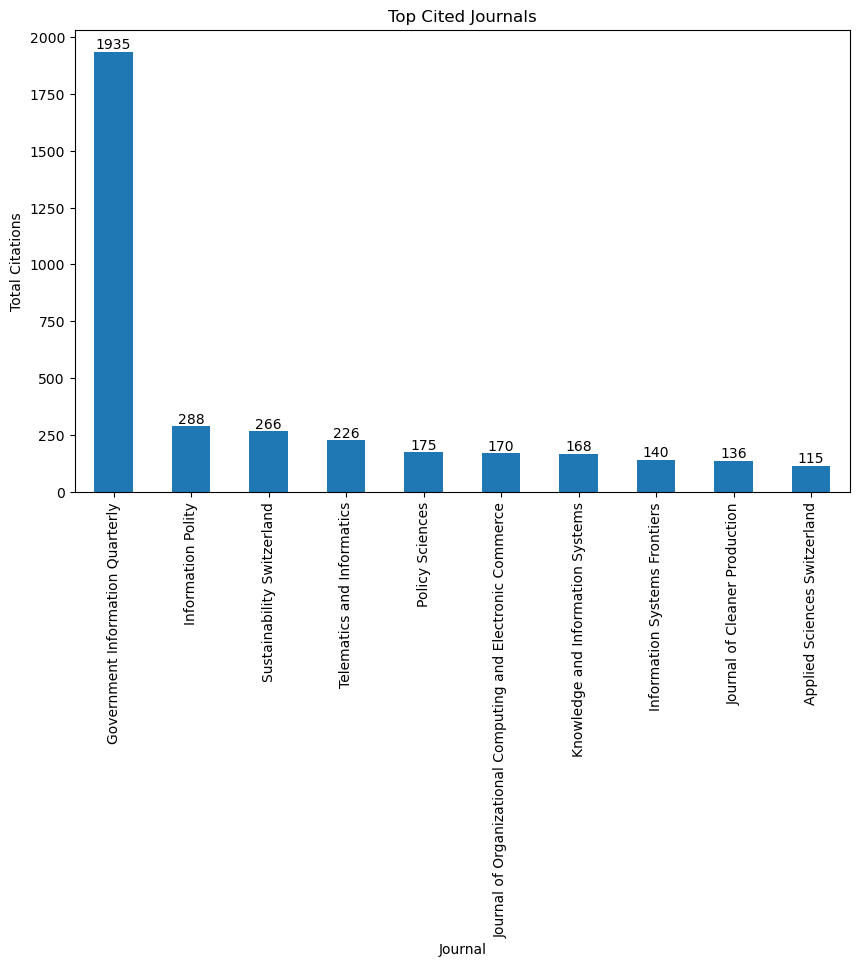

In [68]:
# Plot of Most Cited Journals
plt.figure(figsize=(10, 6))
ax = journal_citations.plot(kind='bar', title='Top Cited Journals')
plt.xlabel("Journal")
plt.ylabel("Total Citations")

# Add labels directly on top of the bars
ax.bar_label(ax.containers[0])

plt.show()


## Part 4: What?
In this final section, you will analyze the topics and themes within the research, such as keywords, abstract content, and funding sources.

Type of Documents:
Document Type
Article              168
Conference Paper      60
Book Chapter          20
Review                11
Book                   3
Letter                 1
Editorial              1
Conference Review      1
Name: count, dtype: int64


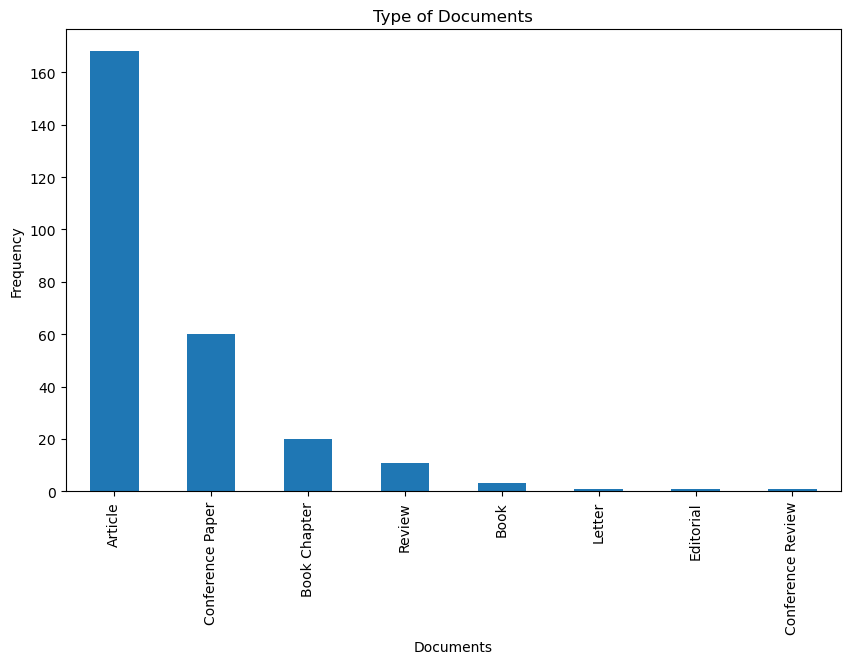

In [70]:
# Most Frequent Keywords
dfScopus['Document Type'] = dfScopus['Document Type'].fillna('')
all_keywords = dfScopus['Document Type'].str.split('; ').explode().value_counts().head(10)
print("Type of Documents:")
print(all_keywords)

# Plot top keywords
plt.figure(figsize=(10, 6))
all_keywords.plot(kind='bar', title='Type of Documents')
plt.xlabel("Documents")
plt.ylabel("Frequency")
plt.show()

Top 10 Author Keywords:
Author Keywords
    265
Name: count, dtype: int64


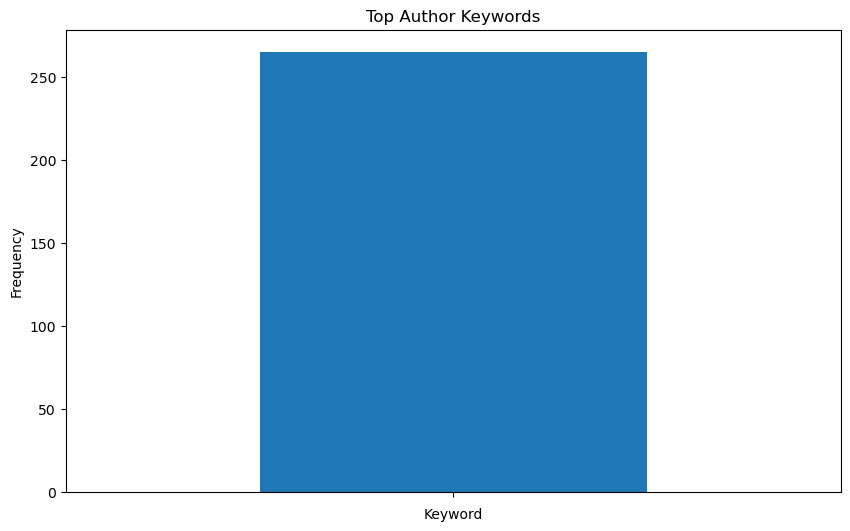

In [69]:
# Most Frequent Keywords
dfScopus['Author Keywords'] = dfScopus['Author Keywords'].fillna('')
all_keywords = dfScopus['Author Keywords'].str.split('; ').explode().value_counts().head(10)
print("Top 10 Author Keywords:")
print(all_keywords)

# Plot top keywords
plt.figure(figsize=(10, 6))
all_keywords.plot(kind='bar', title='Top Author Keywords')
plt.xlabel("Keyword")
plt.ylabel("Frequency")
plt.show()
